<a href="https://colab.research.google.com/github/Muqqadas30/fsdl-my-labs/blob/main/lab01/lab01_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import math
import random
import argparse
from typing import Any, Dict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets
import matplotlib.pyplot as plt

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(device)

cpu


In [2]:
train_raw = datasets.FashionMNIST(root="./data", train=True, download=True)
valid_raw = datasets.FashionMNIST(root="./data", train=False, download=True)

x_train = train_raw.data.float().reshape(-1, 784) / 255.0
y_train = train_raw.targets

x_valid = valid_raw.data.float().reshape(-1, 784) / 255.0
y_valid = valid_raw.targets

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.06MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 137kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.53MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.7MB/s]


In [3]:
print(x_train, y_train, sep="\n")

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])
tensor([9, 0, 0,  ..., 3, 0, 5])


In [4]:
y_train[0], x_train[0, ::2]

(tensor(9),
 tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.2863, 0.0000, 0.0157, 0.0000,
         0.0000, 0.0039, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0118,
         0.1412, 0.4980, 0.2118, 0.0000, 0.0039, 0.0157, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0235, 0.4000, 0.6902, 0.5647, 0.0902,
         0.0000, 0.0000, 0.0392, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.6078, 0.8118, 0.4196, 0.6314, 0.2510, 0.3020, 0.2824, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.8118, 0.8549, 0.8471,
         0.4980,

In [5]:
x_train.ndim, y_train.ndim

(2, 1)

In [6]:
x_train[0, 0], y_train[0]

(tensor(0.), tensor(9))

In [7]:
n, c = x_train.shape
print(x_train.shape)
print(y_train.shape)

torch.Size([60000, 784])
torch.Size([60000])


Shirt


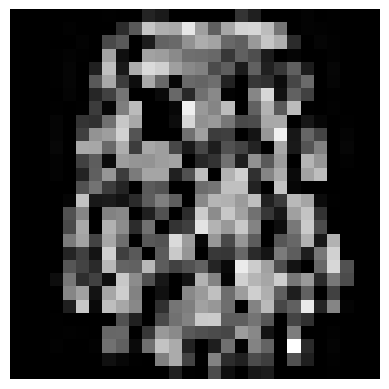

In [8]:
idx = random.randint(0, len(x_train))
example = x_train[idx]

print(class_names[y_train[idx].item()])
plt.imshow(example.reshape(28, 28), cmap="gray")
plt.axis("off")
plt.show()

In [9]:
weights = torch.randn(784, 10) / math.sqrt(784)
weights.requires_grad_()
bias = torch.zeros(10, requires_grad=True)

In [10]:
def linear(x: torch.Tensor) -> torch.Tensor:
    return x @ weights + bias

In [11]:
def log_softmax(x: torch.Tensor) -> torch.Tensor:
    return x - torch.log(torch.sum(torch.exp(x), axis=1))[:, None]

def model(xb: torch.Tensor) -> torch.Tensor:
    return log_softmax(linear(xb))

In [12]:
bs = 64

xb = x_train[0:bs]
outs = model(xb)

print(outs[0], outs.shape)

tensor([-2.6653, -2.3247, -2.8176, -1.2376, -2.9189, -2.2483, -2.4273, -2.6643,
        -3.4366, -2.0165], grad_fn=<SelectBackward0>) torch.Size([64, 10])


In [13]:
def accuracy(out: torch.Tensor, yb: torch.Tensor) -> torch.Tensor:
    preds = torch.argmax(out, dim=1)
    return (preds == yb).float().mean()

In [14]:
yb = y_train[0:bs]
acc = accuracy(outs, yb)
print(acc)

tensor(0.1250)


In [15]:
try:
    acc.backward()
except RuntimeError as e:
    print(e)

element 0 of tensors does not require grad and does not have a grad_fn


In [16]:
def cross_entropy(output: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    return -output[range(target.shape[0]), target].mean()

loss_func = cross_entropy

In [17]:
print(loss_func(outs, yb), -torch.log(torch.tensor(1 / 10)))

tensor(2.4130, grad_fn=<NegBackward0>) tensor(2.3026)


In [18]:
loss = loss_func(outs, yb)
loss.backward()

In [19]:
bias.grad

tensor([-0.0485,  0.0404, -0.0450,  0.0528,  0.0050, -0.0472,  0.0041, -0.0134,
         0.0165,  0.0353])

In [20]:
lr = 0.5
epochs = 2

for epoch in range(epochs):
    for ii in range((n - 1) // bs + 1):
        start_idx = ii * bs
        end_idx = start_idx + bs

        xb = x_train[start_idx:end_idx]
        yb = y_train[start_idx:end_idx]

        pred = model(xb)
        loss = loss_func(pred, yb)
        loss.backward()

        with torch.no_grad():
            weights -= weights.grad * lr
            bias -= bias.grad * lr
            weights.grad.zero_()
            bias.grad.zero_()

In [21]:
print(loss_func(model(xb), yb), accuracy(model(xb), yb))

tensor(2.0232, grad_fn=<NegBackward0>) tensor(0.6562)


In [22]:
loss_func = F.cross_entropy

def model(xb):
    return xb @ weights + bias

In [23]:
print(loss_func(model(xb), yb), accuracy(model(xb), yb))

tensor(2.0232, grad_fn=<NllLossBackward0>) tensor(0.6562)


In [24]:
class FashionLogistic(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(784, 10) / math.sqrt(784))
        self.bias = nn.Parameter(torch.zeros(10))

    def forward(self, xb):
        return xb @ self.weights + self.bias

model = FashionLogistic()
print(model(xb)[:4])
loss = loss_func(model(xb), yb)
loss.backward()
print(model.weights.grad[::17, ::2])

tensor([[ 5.7586e-01,  4.4988e-01, -3.0169e-01,  7.2950e-02, -7.7239e-01,
         -4.4023e-01, -6.0560e-01, -5.2414e-01,  9.0074e-01, -3.5596e-01],
        [ 4.3128e-01,  6.2984e-01,  6.5114e-01, -2.6276e-02, -6.3296e-01,
         -5.0516e-01, -4.0561e-01, -2.7194e-01,  3.8938e-01, -2.0148e-01],
        [ 1.6211e-01,  4.9596e-02,  7.3093e-02,  1.6540e-01, -1.9603e-01,
         -3.2968e-01, -8.7232e-02, -1.8691e-01, -5.5369e-04, -7.1182e-01],
        [ 3.4356e-01, -2.1077e-01, -5.8907e-03, -2.9464e-01, -6.4401e-02,
         -5.3778e-01,  5.7178e-02, -1.1494e-01, -3.3473e-02, -3.3143e-01]],
       grad_fn=<SliceBackward0>)
tensor([[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00],
        [ 9.3945e-03,  7.3136e-03, -2.1786e-02, -1.8439e-02,  2.0279e-02],
        [ 6.4999e-03, -1.4029e-02,  7.8327e-04, -2.7022e-02,  9.2637e-03],
        [ 2.5055e-04,  5.8855e-04, -1.4740e-04,  2.9657e-05,  6.9471e-04],
        [ 6.2389e-02, -2.5812e-02, -1.1434e-01, -9.4704e-02,  6.5995e-

In [25]:
print(*list(model.parameters()), sep="\n")

Parameter containing:
tensor([[ 0.0151, -0.0378,  0.0278,  ..., -0.0295,  0.0017,  0.0317],
        [-0.0531, -0.0297, -0.0263,  ...,  0.0586,  0.0141,  0.0092],
        [-0.0511, -0.0031,  0.0535,  ...,  0.0140,  0.0078,  0.0114],
        ...,
        [-0.0032, -0.0216, -0.0178,  ...,  0.0357, -0.0364,  0.0287],
        [ 0.0750, -0.0022,  0.0354,  ...,  0.0270,  0.0291, -0.0424],
        [ 0.1337,  0.0504,  0.0156,  ...,  0.0736, -0.0295,  0.0326]],
       requires_grad=True)
Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], requires_grad=True)


In [26]:
def fit():
    for epoch in range(epochs):
        for ii in range((n - 1) // bs + 1):
            start_idx = ii * bs
            end_idx = start_idx + bs
            xb = x_train[start_idx:end_idx]
            yb = y_train[start_idx:end_idx]
            pred = model(xb)
            loss = loss_func(pred, yb)

            loss.backward()
            with torch.no_grad():
                for p in model.parameters():
                    p -= p.grad * lr
                model.zero_grad()

fit()

In [27]:
print(accuracy(model(xb), yb))

tensor(0.6562)


In [28]:
class FashionLogistic(nn.Module):
    def __init__(self):
        super().__init__()
        self.lin = nn.Linear(784, 10)

    def forward(self, xb):
        return self.lin(xb)

model = FashionLogistic()
print(loss_func(model(xb), yb))

tensor(2.3812, grad_fn=<NllLossBackward0>)


In [29]:
def configure_optimizer(model: nn.Module) -> optim.Optimizer:
    return optim.Adam(model.parameters(), lr=3e-4)

model = FashionLogistic()
opt = configure_optimizer(model)

print("before training:", loss_func(model(xb), yb))

for epoch in range(epochs):
    for ii in range((n - 1) // bs + 1):
        start_idx = ii * bs
        end_idx = start_idx + bs
        xb = x_train[start_idx:end_idx]
        yb = y_train[start_idx:end_idx]
        pred = model(xb)
        loss = loss_func(pred, yb)

        loss.backward()
        opt.step()
        opt.zero_grad()

print("after training:", loss_func(model(xb), yb))

before training: tensor(2.2873, grad_fn=<NllLossBackward0>)
after training: tensor(0.6186, grad_fn=<NllLossBackward0>)


In [30]:
class BaseDataset(Dataset):
    def __init__(self, data, targets, transform=None, target_transform=None):
        self.data = data
        self.targets = targets
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x, y = self.data[idx], self.targets[idx]
        if self.transform:
            x = self.transform(x)
        if self.target_transform:
            y = self.target_transform(y)
        return x, y

train_ds = BaseDataset(x_train, y_train)

In [31]:
train_dataloader = DataLoader(train_ds, batch_size=bs)

def fit(self: nn.Module, train_dataloader: DataLoader):
    opt = configure_optimizer(self)
    for epoch in range(epochs):
        for xb, yb in train_dataloader:
            pred = self(xb)
            loss = loss_func(pred, yb)
            loss.backward()
            opt.step()
            opt.zero_grad()

FashionLogistic.fit = fit

model = FashionLogistic()
model.fit(train_dataloader)
print(loss_func(model(xb), yb))

tensor(0.6181, grad_fn=<NllLossBackward0>)


In [32]:
FC1_DIM = 1024
FC2_DIM = 128
FC_DROPOUT = 0.5

class MLP(nn.Module):
    """Simple MLP for classifying Fashion-MNIST images."""
    def __init__(self, data_config: Dict[str, Any], args: argparse.Namespace = None) -> None:
        super().__init__()
        self.args = vars(args) if args is not None else {}
        self.data_config = data_config
        input_dim = np.prod(self.data_config["input_dims"])
        num_classes = len(self.data_config["mapping"])
        fc1_dim = self.args.get("fc1", FC1_DIM)
        fc2_dim = self.args.get("fc2", FC2_DIM)
        dropout_p = self.args.get("fc_dropout", FC_DROPOUT)

        self.fc1 = nn.Linear(input_dim, fc1_dim)
        self.dropout = nn.Dropout(dropout_p)
        self.fc2 = nn.Linear(fc1_dim, fc2_dim)
        self.fc3 = nn.Linear(fc2_dim, num_classes)

    def forward(self, x):
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc3(x)
        return x

MLP.fit = fit

In [33]:
data_config = {"input_dims": (784,), "mapping": {i: name for i, name in enumerate(class_names)}}
model = MLP(data_config)
model

MLP(
  (fc1): Linear(in_features=784, out_features=1024, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=1024, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)

In [34]:
%%time
print("before training:", loss_func(model(xb), yb))

train_ds = BaseDataset(x_train, y_train)
train_dataloader = DataLoader(train_ds, batch_size=bs)
model.fit(train_dataloader)

print("after training:", loss_func(model(xb), yb))

before training: tensor(2.2976, grad_fn=<NllLossBackward0>)
after training: tensor(0.4162, grad_fn=<NllLossBackward0>)
CPU times: user 25.9 s, sys: 31.2 ms, total: 26 s
Wall time: 27.1 s


In [35]:
model.to(device)
loss_func(model(xb.to(device)), yb.to(device))

tensor(0.3506, grad_fn=<NllLossBackward0>)

In [36]:
def push_to_device(tensor):
    return tensor.to(device)

class FashionMNISTDataModule:
    def __init__(self, bs=32):
        self.bs = bs

    def setup(self):
        self.train_ds = BaseDataset(x_train, y_train, transform=push_to_device, target_transform=push_to_device)
        self.valid_ds = BaseDataset(x_valid, y_valid, transform=push_to_device, target_transform=push_to_device)

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.bs, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.valid_ds, batch_size=2 * self.bs, shuffle=False)

In [37]:
def fit(self: nn.Module, datamodule):
    datamodule.setup()
    val_dataloader = datamodule.val_dataloader()

    self.eval()
    with torch.no_grad():
        valid_loss = sum(loss_func(self(xb), yb) for xb, yb in val_dataloader)
    print("before start of training:", valid_loss / len(val_dataloader))

    opt = configure_optimizer(self)
    train_dataloader = datamodule.train_dataloader()

    for epoch in range(epochs):
        self.train()
        for xb, yb in train_dataloader:
            pred = self(xb)
            loss = loss_func(pred, yb)
            loss.backward()
            opt.step()
            opt.zero_grad()

        self.eval()
        with torch.no_grad():
            valid_loss = sum(loss_func(self(xb), yb) for xb, yb in val_dataloader)
        print(epoch, valid_loss / len(val_dataloader))

MLP.fit = fit

In [38]:
model = MLP(data_config)
model.to(device)

datamodule = FashionMNISTDataModule(bs=32)
model.fit(datamodule=datamodule)

before start of training: tensor(2.3064)
0 tensor(0.4596)
1 tensor(0.4139)
